# Heterogeneous GAT, 3 layers (with residual)

1. **3 layers** — each paper sees its 3-hop citation neighborhood.
2. **Residual connection** between layer 1 and layer 2 outputs. Mitigates over-smoothing — at 3 hops in a dense graph, embeddings tend to homogenize without skip connections. The residual lets layer 2 refine layer 1's representation rather than replace it.
3. **`NUM_EPOCHS=80`**.
4. **Per-layer HAN aggregator** — 3 places where the relation-attention can saturate. We log all three layer weights at every eval epoch.

## Architecture

```
Layer 1 (per relation):  GATConv(768 -> 64, heads=4, concat=True)  ->  (N, 256)
                          x 2 relations
HAN aggregator 1:        softmax over relations  ->  h1: (N, 256)
ELU + dropout

Layer 2 (per relation):  GATConv(256 -> 64, heads=4, concat=True)  ->  (N, 256)
                          x 2 relations
HAN aggregator 2:        softmax over relations  ->  h2_raw: (N, 256)
Residual:                h2 = h2_raw + h1
ELU + dropout

Layer 3 (per relation):  GATConv(256 -> 256, heads=1, concat=False)  ->  (N, 256)
                          x 2 relations
HAN aggregator 3:        softmax over relations  ->  out: (N, 256)
```

Output is 256-dim.


## Imports


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from pathlib import Path

from torch_geometric.nn import GATConv

## Reproducibility and device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration

- `NUM_EPOCHS=80` (longer because deeper).
- `USE_RESIDUAL_LAYER2=True` — turn off to ablate the skip connection.
- `MIDDLE_HEADS=4` — heads in the new middle layer. Concats to 256-dim hidden.


In [3]:
# --- Paths ---
PROCESSED_DIR = Path("./data/processed_v2")
MODEL_OUT_DIR = Path("./models")
PLOTS_OUT_DIR = Path("./data")

# --- Negative strategy ---
NEG_STRATEGY = 'mixed'

# --- Hetero relations ---
RELATIONS = ['cites', 'cited_by']

# --- Encoder (3-layer) ---
INPUT_DIM = 768
HIDDEN_DIM = 256
OUTPUT_DIM = 256
GAT_HEADS_LAYER1 = 4
MIDDLE_HEADS = 4               # heads in the new middle layer
GAT_HEADS_LAYER3 = 1           # output layer
GAT_NEGATIVE_SLOPE = 0.2
DROPOUT = 0.2
ATTN_DROPOUT = 0.0
USE_RESIDUAL_LAYER2 = True     # skip connection h1 → h2 to mitigate over-smoothing

# --- HAN-style semantic attention ---
SEMANTIC_ATTN_DIM = 128

# --- Decoder ---
DECODER_HIDDEN_DIM = 128
DECODER_DROPOUT = 0.0

# --- Optimization ---
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 0.0

# --- Training ---
NUM_EPOCHS = 80                # bumped from 60 — deeper model, val was still climbing at epoch 60 in 2L run
BATCH_SIZE = 512
EVAL_EVERY = 5
GNN_GRAD_SAMPLE_SIZE = 32
EVAL_BATCH_SIZE = 64

print(f"Data dir:      {PROCESSED_DIR}")
print(f"Relations:     {RELATIONS}")
print(f"NEG_STRATEGY:  {NEG_STRATEGY}")
print(f"3-layer HetGAT: heads_l1={GAT_HEADS_LAYER1}, middle_heads={MIDDLE_HEADS}, heads_l3={GAT_HEADS_LAYER3}")
print(f"Dims:          {INPUT_DIM} -> {HIDDEN_DIM} -> {HIDDEN_DIM} -> {OUTPUT_DIM}")
print(f"Residual L2:   {USE_RESIDUAL_LAYER2}")
print(f"Schedule:      {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}")

Data dir:      data/processed_v2
Relations:     ['cites', 'cited_by']
NEG_STRATEGY:  mixed
3-layer HetGAT: heads_l1=4, middle_heads=4, heads_l3=1
Dims:          768 -> 256 -> 256 -> 256
Residual L2:   True
Schedule:      80 epochs, batch 512, eval every 5


## Step 1 — Load data

Loads `train_years.pt`, `metadata.pt`, `val.pt`. Per-year files loaded lazily inside the loop.


In [4]:
train_years = torch.load(PROCESSED_DIR / "train_years.pt", weights_only=False)
metadata = torch.load(PROCESSED_DIR / "metadata.pt", weights_only=False)
val_data = torch.load(PROCESSED_DIR / "val.pt", weights_only=False)

print(f"Training years ({len(train_years)}): {train_years}")
print(f"Val edge types: {val_data['hetero_graph'].edge_types}")
print(f"Val examples:   {len(val_data['supervision']):,}")
assert metadata['embed_dim'] == INPUT_DIM

sample_data = torch.load(PROCESSED_DIR / f"train_year_{train_years[0]}.pt", weights_only=False)
g = sample_data['hetero_graph']
for et in g.edge_types:
    print(f"  edge {et}: {g[et].edge_index.shape[1]:,} edges")
assert ('paper', 'cites', 'paper') in g.edge_types
assert ('paper', 'cited_by', 'paper') in g.edge_types
if sample_data['supervision']:
    ex = sample_data['supervision'][0]
    assert 'negatives_random' in ex and 'negatives_hard' in ex

Training years (12): [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Val edge types: [('paper', 'cites', 'paper'), ('paper', 'cited_by', 'paper')]
Val examples:   43,562
  edge ('paper', 'cites', 'paper'): 644,493 edges
  edge ('paper', 'cited_by', 'paper'): 644,493 edges


## Step 2 — HAN-style semantic attention

We instantiate one HAN module per layer (3 of them in this notebook). Saturating to ~1/0 at deeper layers is common — a known HAN failure mode and a key thing to monitor here.


In [5]:
class SemanticAttention(nn.Module):
    def __init__(self, in_dim, attn_dim=128):
        super().__init__()
        self.proj = nn.Linear(in_dim, attn_dim)
        self.q = nn.Parameter(torch.empty(attn_dim))
        nn.init.xavier_uniform_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)
        nn.init.normal_(self.q, mean=0.0, std=0.1)

    def forward(self, rel_outputs):
        stacked = torch.stack(rel_outputs, dim=0)
        z = torch.tanh(self.proj(stacked))
        scores = (z * self.q).sum(dim=-1).mean(dim=1)
        weights = F.softmax(scores, dim=0)
        return (stacked * weights.view(-1, 1, 1)).sum(dim=0)

    def relation_weights(self, rel_outputs):
        stacked = torch.stack(rel_outputs, dim=0)
        z = torch.tanh(self.proj(stacked))
        scores = (z * self.q).sum(dim=-1).mean(dim=1)
        return F.softmax(scores, dim=0).detach()

_sa = SemanticAttention(in_dim=8, attn_dim=4)
_outs = [torch.randn(5, 8), torch.randn(5, 8)]
with torch.no_grad():
    _agg = _sa(_outs)
    _w = _sa.relation_weights(_outs)
assert _agg.shape == (5, 8) and abs(_w.sum().item() - 1.0) < 1e-5
print(f"[PASS] SemanticAttention | weights sum = {_w.sum().item():.6f}")
del _sa, _outs, _agg, _w

[PASS] SemanticAttention | weights sum = 1.000000


## Step 3 — 3-layer Hetero GAT encoder (with residual)

Three layers; HAN aggregator after each. Layer 2 has a **residual connection** from layer 1's output: `h2 = h2_raw + h1`. The residual:
- Lets gradients flow more easily through the deep stack.
- Prevents the model from over-smoothing in the middle layer.
- Doesn't add params (just an addition).

Layer 3 doesn't get a residual — output dim differs from intermediate (would need a projection). Keeping output clean.

`report_relation_weights` returns weights at all three layers — useful diagnostic to see whether the middle layer also collapses to one relation.


In [6]:
class HeteroGAT3LEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, relations,
                 heads_l1=4, middle_heads=4, heads_l3=1,
                 dropout=0.2, attn_dropout=0.0,
                 negative_slope=0.2, semantic_attn_dim=128,
                 use_residual_layer2=True):
        super().__init__()
        assert hidden_dim % heads_l1 == 0
        assert hidden_dim % middle_heads == 0
        per_head_l1 = hidden_dim // heads_l1
        per_head_mid = hidden_dim // middle_heads
        self.relations = list(relations)
        self.dropout = dropout
        self.use_residual_layer2 = use_residual_layer2

        # Layer 1: input → hidden, multi-head, concat
        self.conv1 = nn.ModuleDict({
            rel: GATConv(input_dim, per_head_l1, heads=heads_l1, concat=True,
                         negative_slope=negative_slope, dropout=attn_dropout)
            for rel in self.relations
        })
        self.attn1 = SemanticAttention(in_dim=hidden_dim, attn_dim=semantic_attn_dim)

        # Layer 2 (NEW): hidden → hidden, multi-head, concat. Residual added afterward.
        self.conv2 = nn.ModuleDict({
            rel: GATConv(hidden_dim, per_head_mid, heads=middle_heads, concat=True,
                         negative_slope=negative_slope, dropout=attn_dropout)
            for rel in self.relations
        })
        self.attn2 = SemanticAttention(in_dim=hidden_dim, attn_dim=semantic_attn_dim)

        # Layer 3: hidden → output, single-head
        self.conv3 = nn.ModuleDict({
            rel: GATConv(hidden_dim, output_dim, heads=heads_l3, concat=(heads_l3 > 1),
                         negative_slope=negative_slope, dropout=attn_dropout)
            for rel in self.relations
        })
        self.attn3 = SemanticAttention(in_dim=output_dim, attn_dim=semantic_attn_dim)

    def forward(self, x, edge_index_dict):
        # Layer 1
        h1_per_rel = [self.conv1[rel](x, edge_index_dict[rel]) for rel in self.relations]
        h1 = self.attn1(h1_per_rel)                                  # (N, hidden_dim)
        h1 = F.elu(h1)
        h1 = F.dropout(h1, p=self.dropout, training=self.training)

        # Layer 2 with optional residual
        h2_per_rel = [self.conv2[rel](h1, edge_index_dict[rel]) for rel in self.relations]
        h2 = self.attn2(h2_per_rel)                                  # (N, hidden_dim)
        if self.use_residual_layer2:
            h2 = h2 + h1                                              # skip connection
        h2 = F.elu(h2)
        h2 = F.dropout(h2, p=self.dropout, training=self.training)

        # Layer 3 (output)
        h3_per_rel = [self.conv3[rel](h2, edge_index_dict[rel]) for rel in self.relations]
        return self.attn3(h3_per_rel)                                # (N, output_dim)

    @torch.no_grad()
    def report_relation_weights(self, x, edge_index_dict):
        h1p = [self.conv1[rel](x, edge_index_dict[rel]) for rel in self.relations]
        w1 = self.attn1.relation_weights(h1p)
        h1 = F.elu(self.attn1(h1p))
        h2p = [self.conv2[rel](h1, edge_index_dict[rel]) for rel in self.relations]
        w2 = self.attn2.relation_weights(h2p)
        h2 = self.attn2(h2p)
        if self.use_residual_layer2:
            h2 = h2 + h1
        h2 = F.elu(h2)
        h3p = [self.conv3[rel](h2, edge_index_dict[rel]) for rel in self.relations]
        w3 = self.attn3.relation_weights(h3p)
        return {'layer1': dict(zip(self.relations, w1.tolist())),
                'layer2': dict(zip(self.relations, w2.tolist())),
                'layer3': dict(zip(self.relations, w3.tolist()))}

# Sanity
_te = HeteroGAT3LEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, middle_heads=MIDDLE_HEADS, heads_l3=GAT_HEADS_LAYER3,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, semantic_attn_dim=SEMANTIC_ATTN_DIM,
    use_residual_layer2=USE_RESIDUAL_LAYER2,
)
_g = sample_data['hetero_graph']
_eid = {rel: _g['paper', rel, 'paper'].edge_index for rel in RELATIONS}
_te.eval()
with torch.no_grad():
    _out = _te(_g['paper'].x, _eid)
assert _out.shape == (_g['paper'].num_nodes, OUTPUT_DIM)
assert not torch.isnan(_out).any() and not torch.isinf(_out).any()
print(f"Encoder out: {_out.shape}")
print(f"Encoder params: {sum(p.numel() for p in _te.parameters()):,}")
print(f"Init relation weights: {_te.report_relation_weights(_g['paper'].x, _eid)}")
print("[PASS] HeteroGAT3LEncoder")
del _te, _g, _eid, _out

Encoder out: torch.Size([107163, 256])
Encoder params: 759,040
Init relation weights: {'layer1': {'cites': 0.3080843389034271, 'cited_by': 0.6919156312942505}, 'layer2': {'cites': 0.19594097137451172, 'cited_by': 0.8040590286254883}, 'layer3': {'cites': 0.5093075633049011, 'cited_by': 0.49069246649742126}}
[PASS] HeteroGAT3LEncoder


## Step 4 — MLP decoder


In [7]:
class MLPDecoder(nn.Module):
    def __init__(self, emb_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(2 * emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, author_emb, paper_emb):
        combined = torch.cat([author_emb, paper_emb], dim=-1)
        h = F.relu(self.fc1(combined))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc2(h).squeeze(-1)

_td = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT)
_fa, _fp = torch.randn(16, OUTPUT_DIM), torch.randn(16, OUTPUT_DIM)
with torch.no_grad():
    _s = _td(_fa, _fp)
assert _s.shape == (16,) and not torch.isnan(_s).any()
print(f"Decoder params: {sum(p.numel() for p in _td.parameters()):,}")
print("[PASS] decoder")
del _td, _fa, _fp, _s

Decoder params: 65,793
[PASS] decoder


## Step 5 — Utilities (mean-pool, BPR, NEG_STRATEGY helper)


In [8]:
def compute_author_embeddings(paper_embeddings, supervision_examples):
    embs = []
    for ex in supervision_examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=paper_embeddings.device)
        embs.append(paper_embeddings[hids].mean(dim=0))
    return torch.stack(embs)

def bpr_loss(pos_scores, neg_scores):
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

def get_train_negatives(ex, strategy):
    if strategy == 'random':
        return list(ex['negatives_random'])
    if strategy == 'hard':
        return list(ex['negatives_hard'])
    n = len(ex['negatives_random'])
    half = n // 2
    return list(ex['negatives_random'][:half]) + list(ex['negatives_hard'][:n - half])

assert abs(bpr_loss(torch.tensor([0., 0.]), torch.tensor([0., 0.])).item() - 0.6931) < 0.01
print("[PASS] utilities")

[PASS] utilities


## Step 6 — Hetero-graph helpers


In [9]:
def get_edge_index_dict(g, relations=RELATIONS):
    return {rel: g['paper', rel, 'paper'].edge_index for rel in relations}

def move_hetero_to_device(g, device, relations=RELATIONS):
    g['paper'].x = g['paper'].x.to(device)
    for rel in relations:
        g['paper', rel, 'paper'].edge_index = g['paper', rel, 'paper'].edge_index.to(device)
    return g

## Step 7 — Train one year

Encoder forward signature is `(x, edge_index_dict)`. The encoder being 3-layer is transparent to the training loop.


In [10]:
def train_one_year(encoder, decoder, optimizer, year_data, device,
                   batch_size=512, gnn_sample_size=32, grad_clip=0.0,
                   neg_strategy='mixed'):
    encoder.train(); decoder.train()
    g = move_hetero_to_device(year_data['hetero_graph'], device)
    eid = get_edge_index_dict(g)
    examples = year_data['supervision']
    if not examples:
        return 0.0

    paper_embs = encoder(g['paper'].x, eid).detach()

    indices = list(range(len(examples)))
    random.shuffle(indices)
    total_loss, num_batches = 0.0, 0

    for batch_start in range(0, len(indices), batch_size):
        bidx = indices[batch_start:batch_start + batch_size]
        bex = [examples[i] for i in bidx]
        author_embs = compute_author_embeddings(paper_embs, bex)

        all_a, all_p, bounds = [], [], []
        offset = 0
        for i, ex in enumerate(bex):
            negs = get_train_negatives(ex, neg_strategy)
            if not negs:
                continue
            n_pos, n_neg = len(ex['positive_locals']), len(negs)
            pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
            neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
            all_a.append(author_embs[i].unsqueeze(0).expand(n_pos + n_neg, -1))
            all_p.append(torch.cat([paper_embs[pos_ids], paper_embs[neg_ids]], dim=0))
            bounds.append((offset, n_pos, n_neg))
            offset += n_pos + n_neg
        if not all_a:
            continue

        flat_a = torch.cat(all_a, dim=0)
        flat_p = torch.cat(all_p, dim=0)
        scores = decoder(flat_a, flat_p)

        batch_loss = torch.tensor(0.0, device=device)
        for start, n_pos, n_neg in bounds:
            ps = scores[start:start + n_pos]
            ns = scores[start + n_pos:start + n_pos + n_neg]
            batch_loss = batch_loss + bpr_loss(ps, ns)
        batch_loss = batch_loss / len(bounds)

        optimizer.zero_grad()
        batch_loss.backward()
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()),
                max_norm=grad_clip,
            )
        optimizer.step()
        total_loss += batch_loss.item()
        num_batches += 1

    sample = random.sample(examples, min(gnn_sample_size, len(examples)))
    pe_grad = encoder(g['paper'].x, eid)
    ae = compute_author_embeddings(pe_grad, sample)
    gnn_loss = torch.tensor(0.0, device=device)
    for i, ex in enumerate(sample):
        negs = get_train_negatives(ex, neg_strategy)
        if not negs:
            continue
        a = ae[i]
        pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
        neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
        ps = decoder(a.unsqueeze(0).expand(len(pos_ids), -1), pe_grad[pos_ids])
        ns = decoder(a.unsqueeze(0).expand(len(neg_ids), -1), pe_grad[neg_ids])
        gnn_loss = gnn_loss + bpr_loss(ps, ns)
    gnn_loss = gnn_loss / max(len(sample), 1)
    optimizer.zero_grad()
    gnn_loss.backward()
    if grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()),
            max_norm=grad_clip,
        )
    optimizer.step()

    del paper_embs, pe_grad
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return total_loss / max(num_batches, 1)

## Step 8 — Eval on the 1K mixed candidate pool


In [11]:
@torch.no_grad()
def evaluate(encoder, decoder, eval_data, device, eval_batch_size=64):
    encoder.eval(); decoder.eval()
    g = move_hetero_to_device(eval_data['hetero_graph'], device)
    eid = get_edge_index_dict(g)
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}

    paper_embs = encoder(g['paper'].x, eid).cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    decoder_cpu = decoder.cpu()

    hits10, mrrs = [], []
    for batch_start in range(0, len(examples), eval_batch_size):
        for ex in examples[batch_start:batch_start + eval_batch_size]:
            hids = torch.tensor(ex['history_locals'], dtype=torch.long)
            a = paper_embs[hids].mean(dim=0)
            pos = ex['positive_locals']
            neg = ex['negative_locals_mixed']
            cand = pos + neg
            cids = torch.tensor(cand, dtype=torch.long)
            cembs = paper_embs[cids]
            scores = decoder_cpu(a.unsqueeze(0).expand(len(cand), -1), cembs)
            _, ranked = scores.sort(descending=True)
            n_pos = len(pos)
            best = float('inf')
            for rk, idx in enumerate(ranked.tolist()):
                if idx < n_pos:
                    best = rk + 1; break
            hits10.append(1.0 if best <= 10 else 0.0)
            mrrs.append(1.0 / best if best != float('inf') else 0.0)
    decoder.to(device)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

## Step 9 — Full-pool eval (T1)


In [12]:
@torch.no_grad()
def evaluate_full_pool(encoder, decoder, eval_data, device):
    encoder.eval(); decoder.eval()
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}
    if 'known_locals' not in examples[0]:
        raise KeyError("Full-pool eval requires 'known_locals'.")

    g = move_hetero_to_device(eval_data['hetero_graph'], device)
    eid = get_edge_index_dict(g)
    paper_embs = encoder(g['paper'].x, eid)
    N = paper_embs.shape[0]

    hits10, mrrs = [], []
    for ex in examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=device)
        a = paper_embs[hids].mean(dim=0)
        pos = set(ex['positive_locals'])
        known_only = set(ex['known_locals']) - pos

        scores = decoder(a.unsqueeze(0).expand(N, -1), paper_embs)
        if known_only:
            mask = torch.tensor(list(known_only), dtype=torch.long, device=device)
            scores[mask] = float('-inf')

        pos_tensor = torch.tensor(list(pos), dtype=torch.long, device=device)
        _, ranked = scores.sort(descending=True)
        in_pos = torch.isin(ranked, pos_tensor)
        nz = in_pos.nonzero()
        best = (nz[0].item() + 1) if nz.numel() > 0 else float('inf')
        hits10.append(1.0 if best <= 10 else 0.0)
        mrrs.append(1.0 / best if best != float('inf') else 0.0)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

## Step 10 — Initialize model + optimizer


In [13]:
encoder = HeteroGAT3LEncoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM,
    relations=RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, middle_heads=MIDDLE_HEADS, heads_l3=GAT_HEADS_LAYER3,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, semantic_attn_dim=SEMANTIC_ATTN_DIM,
    use_residual_layer2=USE_RESIDUAL_LAYER2,
).to(device)
decoder = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
n_enc = sum(p.numel() for p in encoder.parameters())
n_dec = sum(p.numel() for p in decoder.parameters())
print(f"Encoder params: {n_enc:,}")
print(f"Decoder params: {n_dec:,}")
print(f"Total:          {n_enc + n_dec:,}")

Encoder params: 759,040
Decoder params: 65,793
Total:          824,833


## Step 11 — Training loop

Logs **three** layers' relation weights at every eval epoch. Watch for layer 2 / layer 3 saturation patterns — if both collapse to one relation, the model is effectively degenerating to a homogeneous deep GAT and the heterogeneous design isn't doing useful work in the deeper layers.


In [14]:
train_losses, val_hits, val_mrrs, eval_epochs = [], [], [], []
rel_weight_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = []
    for year in train_years:
        yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
        l = train_one_year(
            encoder, decoder, optimizer, yd, device,
            batch_size=BATCH_SIZE,
            gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
            grad_clip=GRAD_CLIP_NORM,
            neg_strategy=NEG_STRATEGY,
        )
        epoch_losses.append(l)
        del yd
    avg = float(np.mean(epoch_losses))
    train_losses.append(avg)

    if epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS:
        v = evaluate(encoder, decoder, val_data, device, EVAL_BATCH_SIZE)
        val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)
        encoder.eval()
        with torch.no_grad():
            g = move_hetero_to_device(val_data['hetero_graph'], device)
            rw = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))
        rel_weight_history.append({'epoch': epoch, **rw})
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f} | "
              f"Val Hits@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}")
        for layer_key in ('layer1', 'layer2', 'layer3'):
            print(f"           {layer_key}: " + str({k: f'{x:.3f}' for k, x in rw[layer_key].items()}))
    else:
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f}")

Epoch   1/80 | Loss 0.6365
Epoch   2/80 | Loss 0.6121
Epoch   3/80 | Loss 0.5936
Epoch   5/80 | Loss 0.5867 | Val Hits@10 0.2593 | Val MRR 0.1058
           layer1: {'cites': '0.996', 'cited_by': '0.004'}
           layer2: {'cites': '0.528', 'cited_by': '0.472'}
           layer3: {'cites': '0.999', 'cited_by': '0.001'}
Epoch   6/80 | Loss 0.5861
Epoch   7/80 | Loss 0.5850
Epoch   8/80 | Loss 0.5897
Epoch   9/80 | Loss 0.5816
Epoch  10/80 | Loss 0.5777 | Val Hits@10 0.3429 | Val MRR 0.1460
           layer1: {'cites': '0.954', 'cited_by': '0.046'}
           layer2: {'cites': '0.532', 'cited_by': '0.468'}
           layer3: {'cites': '0.997', 'cited_by': '0.003'}
Epoch  11/80 | Loss 0.5784
Epoch  12/80 | Loss 0.5767
Epoch  13/80 | Loss 0.5743
Epoch  14/80 | Loss 0.5765
Epoch  15/80 | Loss 0.5684 | Val Hits@10 0.3029 | Val MRR 0.1335
           layer1: {'cites': '0.968', 'cited_by': '0.032'}
           layer2: {'cites': '0.302', 'cited_by': '0.698'}
           layer3: {'cites': '0.992'

## Step 12 — Plot training curves

Saves to `data/hetero_gat_v2_3layer_training_<NEG_STRATEGY>.png`.


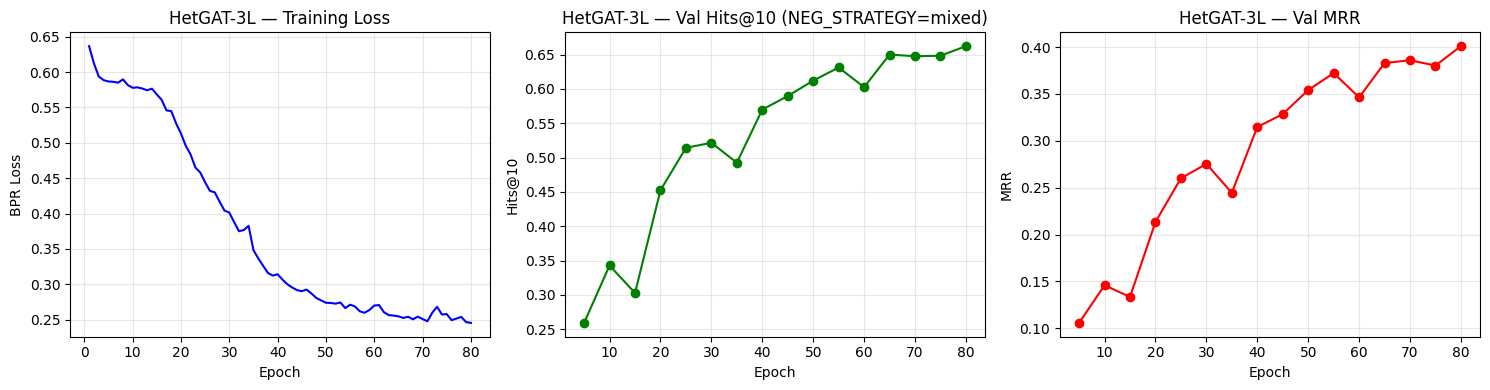

Best val Hits@10: 0.6623 (epoch 80)
Best val MRR:     0.4009 (epoch 80)

Final relation weights:
  layer1: {'cites': 0.6454296112060547, 'cited_by': 0.3545703887939453}
  layer2: {'cites': 0.14500361680984497, 'cited_by': 0.854996383190155}
  layer3: {'cites': 0.7079639434814453, 'cited_by': 0.2920360863208771}


In [15]:
import matplotlib.pyplot as plt

PLOTS_OUT_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')
axes[0].set_title('HetGAT-3L — Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(eval_epochs, val_hits, 'g-o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')
axes[1].set_title(f'HetGAT-3L — Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})'); axes[1].grid(True, alpha=0.3)
axes[2].plot(eval_epochs, val_mrrs, 'r-o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')
axes[2].set_title('HetGAT-3L — Val MRR'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOTS_OUT_DIR / f'hetero_gat_v2_3layer_training_{NEG_STRATEGY}.png'), dpi=100, bbox_inches='tight')
plt.show()
if val_hits:
    print(f"Best val Hits@10: {max(val_hits):.4f} (epoch {eval_epochs[int(np.argmax(val_hits))]})")
    print(f"Best val MRR:     {max(val_mrrs):.4f} (epoch {eval_epochs[int(np.argmax(val_mrrs))]})")
if rel_weight_history:
    print(f"\nFinal relation weights:")
    for layer_key in ('layer1', 'layer2', 'layer3'):
        print(f"  {layer_key}: {rel_weight_history[-1][layer_key]}")

## Step 13 — Final test (1K mixed + full pool)


In [20]:
test_data = torch.load(PROCESSED_DIR / "test.pt", weights_only=False)

test_1k = evaluate(encoder, decoder, test_data, device, EVAL_BATCH_SIZE)
print("=" * 50)
print(f"Hetero GAT v2 3-layer (NEG_STRATEGY={NEG_STRATEGY}) — TEST")
print("=" * 50)
print(f"\n[1K mixed pool, 50/50 hard/random]")
print(f"  Hits@10: {test_1k['hits@10']:.4f}")
print(f"  MRR:     {test_1k['mrr']:.4f}")
print(f"  Authors: {test_1k['num_authors']}")

test_full = evaluate_full_pool(encoder, decoder, test_data, device)
print(f"\n[Full pool — every paper in the pre-test graph]")
print(f"  Hits@10: {test_full['hits@10']:.4f}")
print(f"  MRR:     {test_full['mrr']:.4f}")
print(f"  Authors: {test_full['num_authors']}")

encoder.eval()
with torch.no_grad():
    g = move_hetero_to_device(test_data['hetero_graph'], device)
    rw_test = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))
print(f"\nLearned relation weights at test time:")
for layer_key in ('layer1', 'layer2', 'layer3'):
    print(f"  {layer_key}: " + str({k: f'{x:.3f}' for k, x in rw_test[layer_key].items()}))

Hetero GAT v2 3-layer (NEG_STRATEGY=mixed) — TEST

[1K mixed pool, 50/50 hard/random]
  Hits@10: 0.6808
  MRR:     0.4245
  Authors: 37046

[Full pool — every paper in the pre-test graph]
  Hits@10: 0.0507
  MRR:     0.0238
  Authors: 37046

Learned relation weights at test time:
  layer1: {'cites': '0.703', 'cited_by': '0.297'}
  layer2: {'cites': '0.179', 'cited_by': '0.821'}
  layer3: {'cites': '0.657', 'cited_by': '0.343'}


## Step 14 — Save model

Saves to `models/hetero_gat_v2_3layer_<NEG_STRATEGY>.pt`.


In [17]:
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_OUT_DIR / f"hetero_gat_v2_3layer_{NEG_STRATEGY}.pt"

torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'config': {
        'arch': '3-layer hetero GAT (with residual on layer 2)',
        'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,
        'relations': RELATIONS,
        'heads_l1': GAT_HEADS_LAYER1, 'middle_heads': MIDDLE_HEADS, 'heads_l3': GAT_HEADS_LAYER3,
        'gat_negative_slope': GAT_NEGATIVE_SLOPE,
        'dropout': DROPOUT, 'attn_dropout': ATTN_DROPOUT,
        'use_residual_layer2': USE_RESIDUAL_LAYER2,
        'semantic_attn_dim': SEMANTIC_ATTN_DIM,
        'decoder_hidden_dim': DECODER_HIDDEN_DIM, 'decoder_dropout': DECODER_DROPOUT,
        'lr': LR, 'weight_decay': WEIGHT_DECAY, 'grad_clip_norm': GRAD_CLIP_NORM,
        'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE,
        'gnn_grad_sample_size': GNN_GRAD_SAMPLE_SIZE,
        'neg_strategy': NEG_STRATEGY,
        'seed': SEED,
    },
    'val_best': {'hits@10': max(val_hits) if val_hits else 0.0,
                 'mrr': max(val_mrrs) if val_mrrs else 0.0},
    'test_1k_mixed': test_1k,
    'test_full_pool': test_full,
    'train_losses': train_losses,
    'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,
    'rel_weight_history': rel_weight_history,
    'rel_weights_test': rw_test,
    'data_version': 'v2',
    'fos_level': metadata.get('fos_level'),
}, save_path)
print(f"Saved {save_path}")

Saved models/hetero_gat_v2_3layer_mixed.pt


## Summary

**Diagnostic signals to read off the run**:
1. **Val Hits@10 trajectory**: still climbing at epoch 80 -> bump epochs further or add early stopping; plateaued early -> 3 layers don't add (or residual is masking the issue).
2. **Layer 2 + layer 3 relation weights**: if both saturate to one relation (~1/0), the deeper layers aren't using the relational distinction.
3. **Loss vs val gap**: deeper model + 80 epochs is more prone to overfitting. If loss keeps dropping but val plateaus, training is overfitting to the train negatives.

**Knobs to try if the 3-layer run underperforms**:
- Turn off `USE_RESIDUAL_LAYER2` to see if the residual is hiding over-smoothing.
- Drop `MIDDLE_HEADS` to 1 (smaller middle layer, less capacity to overfit).
- Add a softmax temperature to `SemanticAttention` (e.g. `softmax(scores / 2.0)`) to slow saturation.
- Replace HAN softmax with sigmoid gating (each relation independent in [0, 1]).


Resuming from epoch 80; training epochs 81..110
Epoch  81/110 | Loss 0.2412
Epoch  82/110 | Loss 0.2416
Epoch  83/110 | Loss 0.2388
Epoch  84/110 | Loss 0.2429
Epoch  85/110 | Loss 0.2416 | Val Hits@10 0.6615 | Val MRR 0.3975
           layer1: {'cites': '0.597', 'cited_by': '0.403'}
           layer2: {'cites': '0.180', 'cited_by': '0.820'}
           layer3: {'cites': '0.495', 'cited_by': '0.505'}
Epoch  86/110 | Loss 0.2387
Epoch  87/110 | Loss 0.2390
Epoch  88/110 | Loss 0.2413
Epoch  89/110 | Loss 0.2413
Epoch  90/110 | Loss 0.2442 | Val Hits@10 0.6311 | Val MRR 0.3729
           layer1: {'cites': '0.600', 'cited_by': '0.400'}
           layer2: {'cites': '0.126', 'cited_by': '0.874'}
           layer3: {'cites': '0.505', 'cited_by': '0.495'}
Epoch  91/110 | Loss 0.2418
Epoch  92/110 | Loss 0.2371
Epoch  93/110 | Loss 0.2341
Epoch  94/110 | Loss 0.2347
Epoch  95/110 | Loss 0.2342 | Val Hits@10 0.6580 | Val MRR 0.3934
           layer1: {'cites': '0.570', 'cited_by': '0.430'}
     

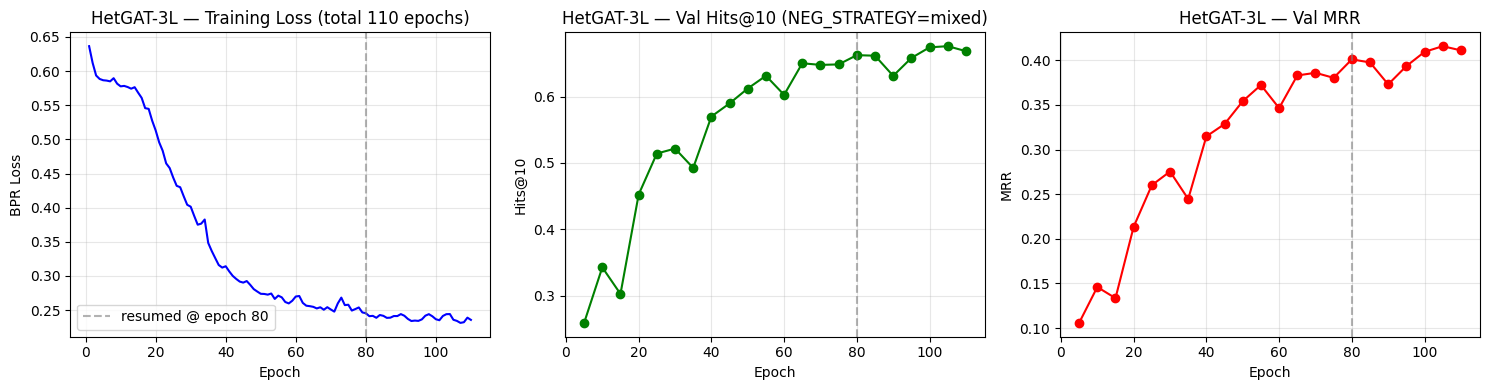


Best val Hits@10 (over 110 epochs): 0.6758 (epoch 105)
Best val MRR:                             0.4157 (epoch 105)
Hetero GAT v2 3-layer (110 total epochs, NEG_STRATEGY=mixed) — TEST

[1K mixed pool, 50/50 hard/random]
  Hits@10: 0.6808
  MRR:     0.4245

[Full pool — every paper in the pre-test graph]
  Hits@10: 0.0507
  MRR:     0.0238

Learned relation weights at test time:
  layer1: {'cites': '0.703', 'cited_by': '0.297'}
  layer2: {'cites': '0.179', 'cited_by': '0.821'}
  layer3: {'cites': '0.657', 'cited_by': '0.343'}

Saved models/hetero_gat_v2_3layer_mixed_ep110.pt


In [19]:
# === Continue training: +30 epochs, replot, retest ===                                                                                                                                                       
EXTRA_EPOCHS = 30                                                                                                                                                                                             
start_epoch = len(train_losses) + 1                                                                                                                                                                           
end_epoch = len(train_losses) + EXTRA_EPOCHS                                                                                                                                                                  
prev_total = len(train_losses)                                                                                                                                                                                
                                                                                                                                                                                                            
print(f"Resuming from epoch {prev_total}; training epochs {start_epoch}..{end_epoch}")                                                                                                                        
                                                                                                                                                                                                            
for epoch in range(start_epoch, end_epoch + 1):                                                                                                                                                               
  epoch_losses = []                                                                                                                                                                                       
  for year in train_years:
      yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
      l = train_one_year(                                                                                                                                                                                   
          encoder, decoder, optimizer, yd, device,
          batch_size=BATCH_SIZE,                                                                                                                                                                            
          gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,                                                                                                                                                           
          grad_clip=GRAD_CLIP_NORM,                                                                                                                                                                         
          neg_strategy=NEG_STRATEGY,                                                                                                                                                                        
      )
      epoch_losses.append(l)                                                                                                                                                                                
      del yd                                                                                                                                                                                              
  avg = float(np.mean(epoch_losses))
  train_losses.append(avg)                                                                                                                                                                                  

  if epoch % EVAL_EVERY == 0 or epoch == end_epoch:                                                                                                                                                         
      v = evaluate(encoder, decoder, val_data, device, EVAL_BATCH_SIZE)                                                                                                                                   
      val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)                                                                                                                   
      encoder.eval()                                                                                                                                                                                        
      with torch.no_grad():                                                                                                                                                                                 
          g = move_hetero_to_device(val_data['hetero_graph'], device)                                                                                                                                       
          rw = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))                                                                                                                      
      rel_weight_history.append({'epoch': epoch, **rw})                                                                                                                                                     
      print(f"Epoch {epoch:>3}/{end_epoch} | Loss {avg:.4f} | "
            f"Val Hits@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}")                                                                                                                                     
      for layer_key in ('layer1', 'layer2', 'layer3'):                                                                                                                                                      
          print(f"           {layer_key}: " + str({k: f'{x:.3f}' for k, x in rw[layer_key].items()}))                                                                                                       
  else:                                                                                                                                                                                                     
      print(f"Epoch {epoch:>3}/{end_epoch} | Loss {avg:.4f}")                                                                                                                                             
                                                                                                                                                                                                            
# --- Replot with full history (resume marker shown) ---                                                                                                                                                      
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))                                                                                                                                                               
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')                                                                                                                                           
axes[0].axvline(prev_total, color='gray', linestyle='--', alpha=0.6, label=f'resumed @ epoch {prev_total}')                                                                                                   
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')                                                                                                                                                   
axes[0].set_title(f'HetGAT-3L — Training Loss (total {len(train_losses)} epochs)')                                                                                                                            
axes[0].grid(True, alpha=0.3); axes[0].legend()                                                                                                                                                               
axes[1].plot(eval_epochs, val_hits, 'g-o')                                                                                                                                                                  
axes[1].axvline(prev_total, color='gray', linestyle='--', alpha=0.6)                                                                                                                                          
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')                                                                                                                                                    
axes[1].set_title(f'HetGAT-3L — Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})')                                                                                                                                   
axes[1].grid(True, alpha=0.3)                                                                                                                                                                                 
axes[2].plot(eval_epochs, val_mrrs, 'r-o')                                                                                                                                                                    
axes[2].axvline(prev_total, color='gray', linestyle='--', alpha=0.6)                                                                                                                                        
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')                                                                                                                                                        
axes[2].set_title('HetGAT-3L — Val MRR'); axes[2].grid(True, alpha=0.3)                                                                                                                                     
plt.tight_layout()                                                                                                                                                                                            
plt.savefig(str(PLOTS_OUT_DIR / f'hetero_gat_v2_3layer_training_{NEG_STRATEGY}_ext{len(train_losses)}ep.png'),                                                                                              
          dpi=100, bbox_inches='tight')                                                                                                                                                                     
plt.show()                                                                                                                                                                                                  
                                                                                                                                                                                                            
print(f"\nBest val Hits@10 (over {len(train_losses)} epochs): {max(val_hits):.4f} "                                                                                                                           
    f"(epoch {eval_epochs[int(np.argmax(val_hits))]})")
print(f"Best val MRR:                             {max(val_mrrs):.4f} "                                                                                                                                       
    f"(epoch {eval_epochs[int(np.argmax(val_mrrs))]})")                                                                                                                                                   
                                                                                                                                                                                                            
# --- Retest (1K mixed + full pool) ---                                                                                                                                                                     
test_1k = evaluate(encoder, decoder, test_data, device, EVAL_BATCH_SIZE)
test_full = evaluate_full_pool(encoder, decoder, test_data, device)                                                                                                                                           
encoder.eval()
with torch.no_grad():                                                                                                                                                                                         
  g = move_hetero_to_device(test_data['hetero_graph'], device)                                                                                                                                            
  rw_test = encoder.report_relation_weights(g['paper'].x, get_edge_index_dict(g))                                                                                                                           
                                                                                                                                                                                                            
print("=" * 60)
print(f"Hetero GAT v2 3-layer ({len(train_losses)} total epochs, NEG_STRATEGY={NEG_STRATEGY}) — TEST")                                                                                                        
print("=" * 60)                                                                                                                                                                                               
print(f"\n[1K mixed pool, 50/50 hard/random]")                                                                                                                                                                
print(f"  Hits@10: {test_1k['hits@10']:.4f}")                                                                                                                                                                 
print(f"  MRR:     {test_1k['mrr']:.4f}")                                                                                                                                                                     
print(f"\n[Full pool — every paper in the pre-test graph]")                                                                                                                                                   
print(f"  Hits@10: {test_full['hits@10']:.4f}")                                                                                                                                                               
print(f"  MRR:     {test_full['mrr']:.4f}")
print(f"\nLearned relation weights at test time:")                                                                                                                                                            
for layer_key in ('layer1', 'layer2', 'layer3'):                                                                                                                                                            
  print(f"  {layer_key}: " + str({k: f'{x:.3f}' for k, x in rw_test[layer_key].items()}))                                                                                                                   
                                                                                                                                                                                                            
# --- Save extended checkpoint (separate from the epoch-80 one) ---                                                                                                                                           
save_path_ext = MODEL_OUT_DIR / f"hetero_gat_v2_3layer_{NEG_STRATEGY}_ep{len(train_losses)}.pt"                                                                                                               
torch.save({                                                                                                                                                                                                  
  'encoder_state_dict': encoder.state_dict(),                                                                                                                                                             
  'decoder_state_dict': decoder.state_dict(),                                                                                                                                                               
  'config': {                                                                                                                                                                                               
      'arch': '3-layer hetero GAT (with residual on layer 2)',
      'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,                                                                                                                           
      'relations': RELATIONS,                                                                                                                                                                               
      'heads_l1': GAT_HEADS_LAYER1, 'middle_heads': MIDDLE_HEADS, 'heads_l3': GAT_HEADS_LAYER3,                                                                                                             
      'gat_negative_slope': GAT_NEGATIVE_SLOPE,                                                                                                                                                             
      'dropout': DROPOUT, 'attn_dropout': ATTN_DROPOUT,                                                                                                                                                     
      'use_residual_layer2': USE_RESIDUAL_LAYER2,                                                                                                                                                           
      'semantic_attn_dim': SEMANTIC_ATTN_DIM,                                                                                                                                                               
      'decoder_hidden_dim': DECODER_HIDDEN_DIM, 'decoder_dropout': DECODER_DROPOUT,                                                                                                                         
      'lr': LR, 'weight_decay': WEIGHT_DECAY, 'grad_clip_norm': GRAD_CLIP_NORM,                                                                                                                             
      'total_epochs': len(train_losses),                                                                                                                                                                    
      'batch_size': BATCH_SIZE, 'gnn_grad_sample_size': GNN_GRAD_SAMPLE_SIZE,                                                                                                                             
      'neg_strategy': NEG_STRATEGY, 'seed': SEED,                                                                                                                                                           
  },                                                                                                                                                                                                      
  'val_best': {'hits@10': max(val_hits), 'mrr': max(val_mrrs)},                                                                                                                                             
  'test_1k_mixed': test_1k,                                                                                                                                                                                 
  'test_full_pool': test_full,
  'train_losses': train_losses,                                                                                                                                                                             
  'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,                                                                                                                                   
  'rel_weight_history': rel_weight_history,
  'rel_weights_test': rw_test,                                                                                                                                                                              
  'data_version': 'v2',                                                                                                                                                                                   
  'fos_level': metadata.get('fos_level'),                                                                                                                                                                   
}, save_path_ext)                                                                                                                                                                                             
print(f"\nSaved {save_path_ext}")
